# Structural Graph Analysis

Measure how FA thresholds affect structural network density, shortest paths, global efficiency, and clustering.

Run this notebook from the project root. See the [project overview](README.md) for the full analysis workflow.


## Structural Connectome Thresholding

FA-thresholded structural graphs were loaded and binarised at 8 thresholds (FA = 0.1, 0.2, ..., 0.8). We first analyse the spatial distribution of voxels remaining in the FA map, then calculate graph metrics as the threshold changes. For disconnected graphs, the largest connected component was analysed. Four graph metrics were computed: edge density, mean shortest path length, global efficiency, and mean clustering coefficient.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
import os


def load_graph_csv(path, get_largest_component=True):
    path = Path(path)

    with open(path, "r") as f:
        lines = f.readlines()

    voxel_count = [int(x) for x in lines[0].split(":", 1)[1].strip().split(",")]
    volume = [float(x) for x in lines[1].split(":", 1)[1].strip().split(",")]
    names = lines[2].split(":", 1)[1].strip().split(",")

    # adj matrix
    matrix = np.loadtxt(path, delimiter=",", skiprows=3)
    # if not connected we pick the largest component
    """
    Carefully consider how to handle missing edges and disconnected vertices, where
    they occur. (If the graph is split into multiple connected components you can focus on the
    largest one.) 
    """
    if not  get_largest_component:
        return {
            "matrix": matrix,
            "names": names,
            "voxel_count": voxel_count,
            "volume": volume,
        }

    if not nx.is_connected(nx.from_numpy_array(matrix)):
        G = nx.from_numpy_array(matrix)
        largest_cc = max(nx.connected_components(G), key=len)
        matrix = matrix[np.ix_(list(largest_cc), list(largest_cc))]
        names = [names[i] for i in largest_cc]
        voxel_count = [voxel_count[i] for i in largest_cc]
        volume = [volume[i] for i in largest_cc]


    return {
        "matrix": matrix,
        "names": names,
        "voxel_count": voxel_count,
        "volume": volume,
    }

# plotting 
def plot_connectome(matrix, names, title="Connectome"):
    matrix = np.array(matrix)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # heatmap
    im = axes[0].imshow(matrix, interpolation="nearest", cmap="binary")
    axes[0].set_title(f"{title} - Adjacency Matrix")
    axes[0].set_xlabel("Region")
    axes[0].set_ylabel("Region")
    plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

    #network graph
    G = nx.from_numpy_array(matrix)

    # shorter labels
    short_labels = {
        i: names[i].replace("_left", "_L").replace("_right", "_R")
        for i in range(len(names))
    }

    pos = nx.spring_layout(G, seed=42)

    nx.draw_networkx_edges(G, pos, ax=axes[1], width=0.6, alpha=0.6)
    nx.draw_networkx_nodes(G, pos, ax=axes[1], node_size=80)
    nx.draw_networkx_labels(G, pos, labels=short_labels, ax=axes[1], font_size=6)

    axes[1].set_title(f"{title} - Network Graph")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()



In [2]:
files = []
connectomes_dir = Path("data/mri/connectomes")
for file in sorted(os.listdir(connectomes_dir)):
    if file.endswith(".csv"):
        files.append(connectomes_dir / file)
print(f"Found {len(files)} connectome files.")


Found 8 connectome files.


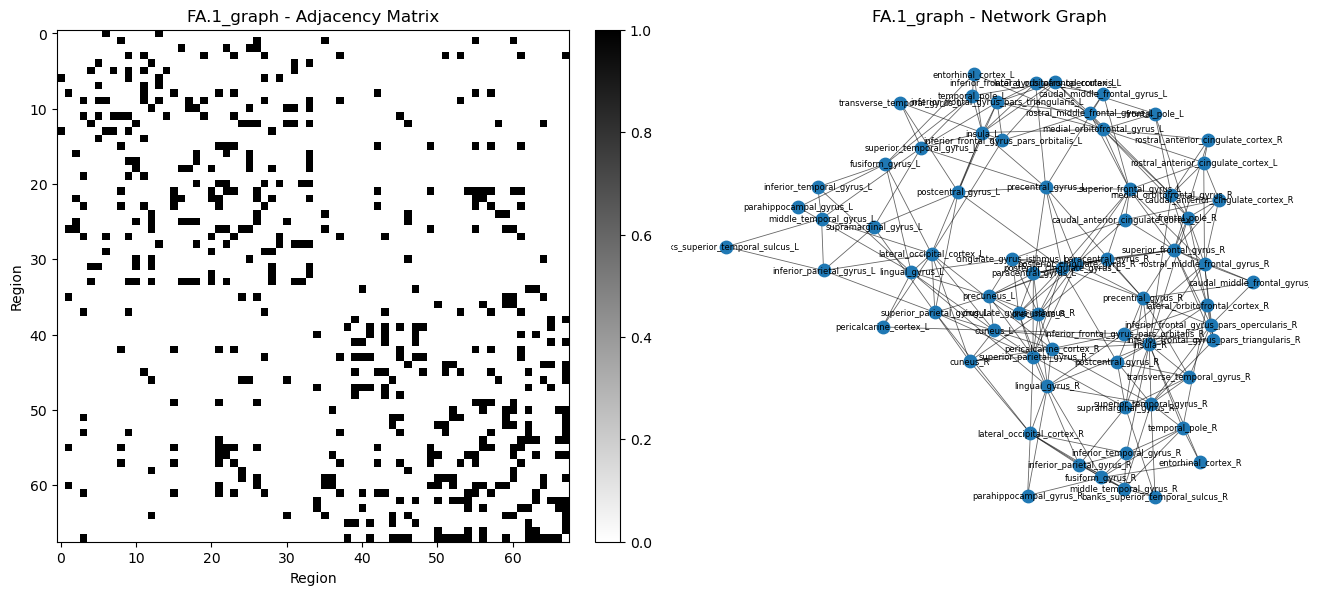

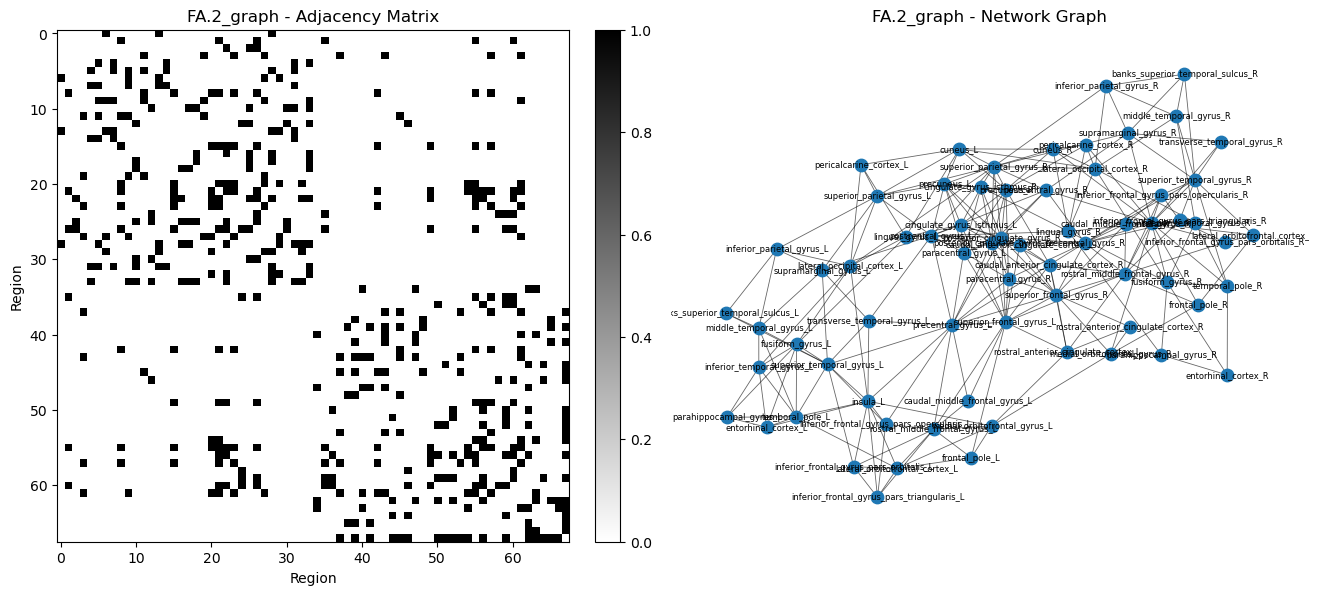

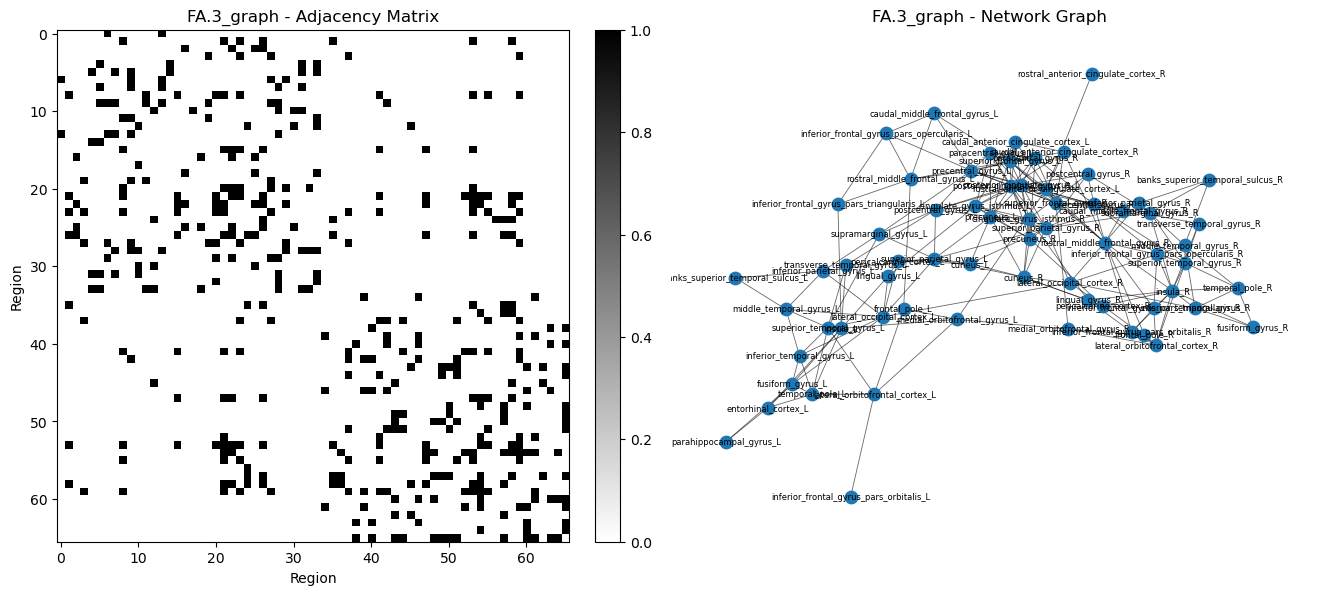

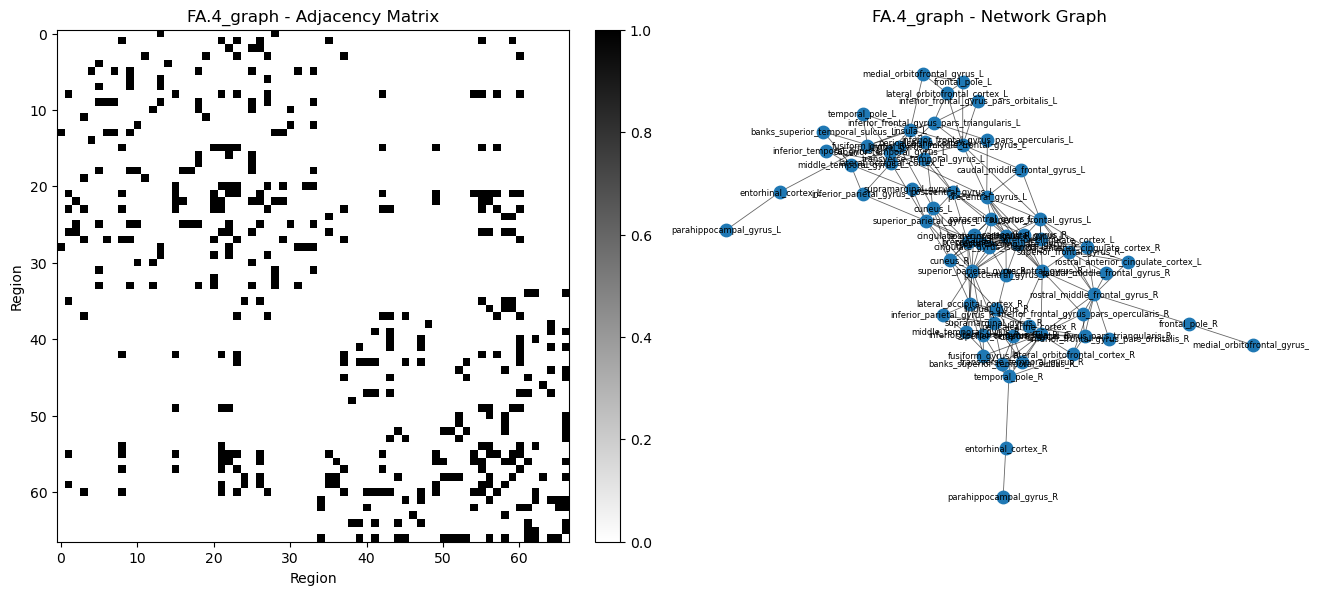

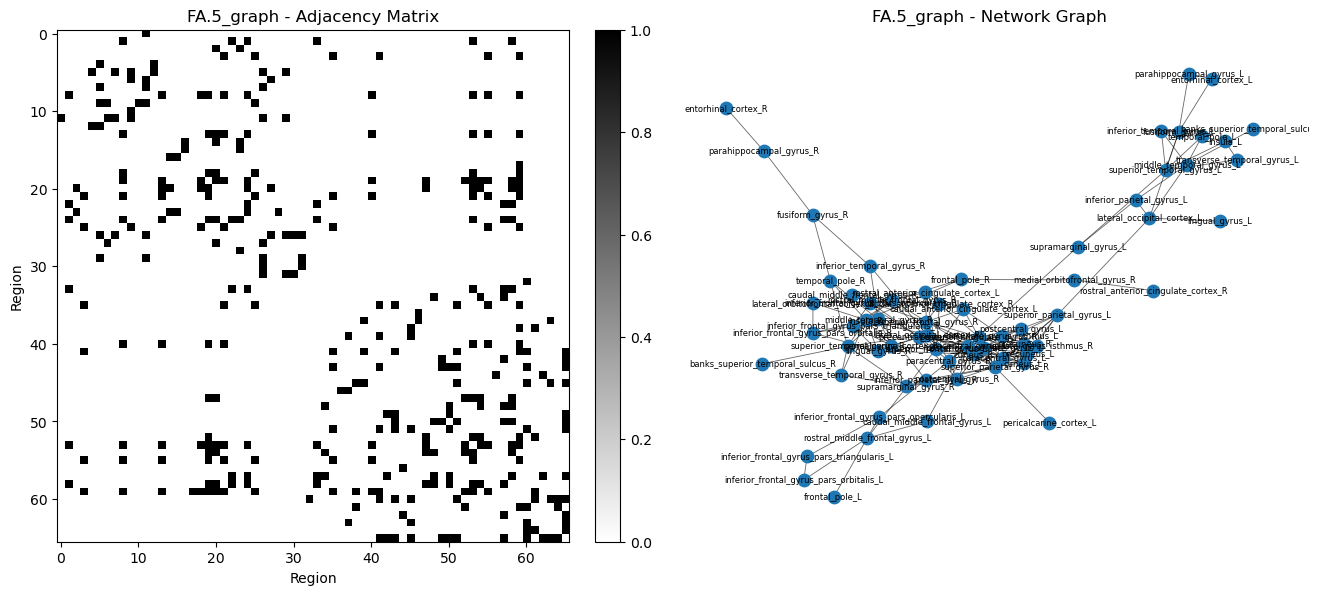

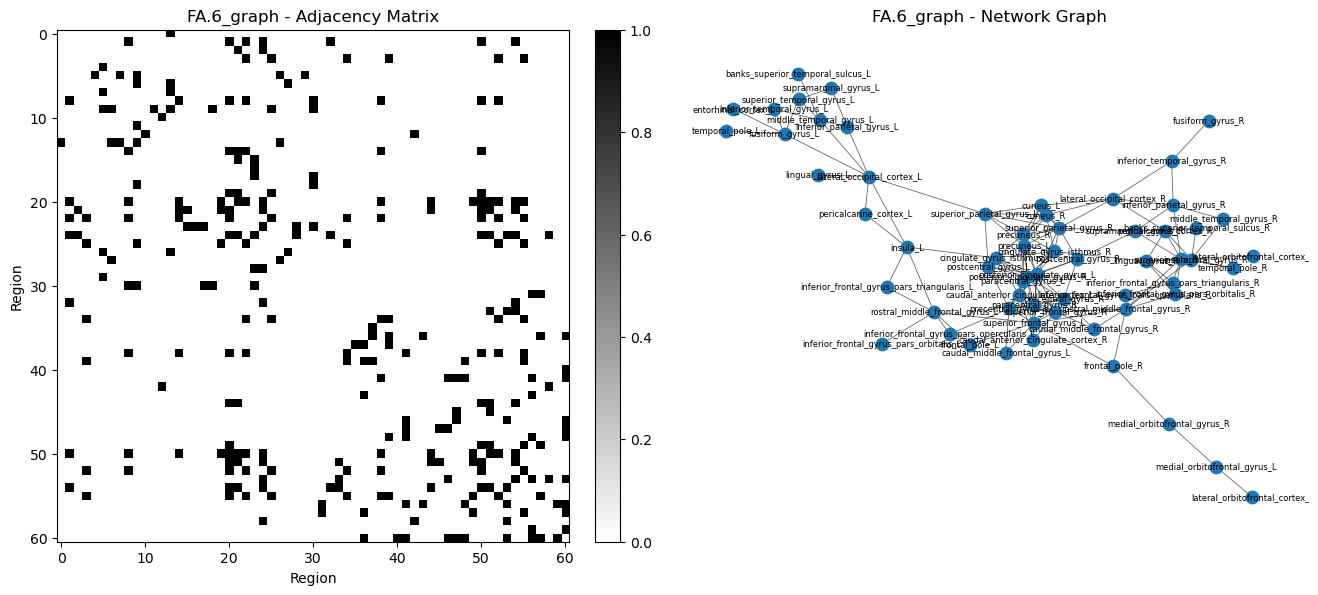

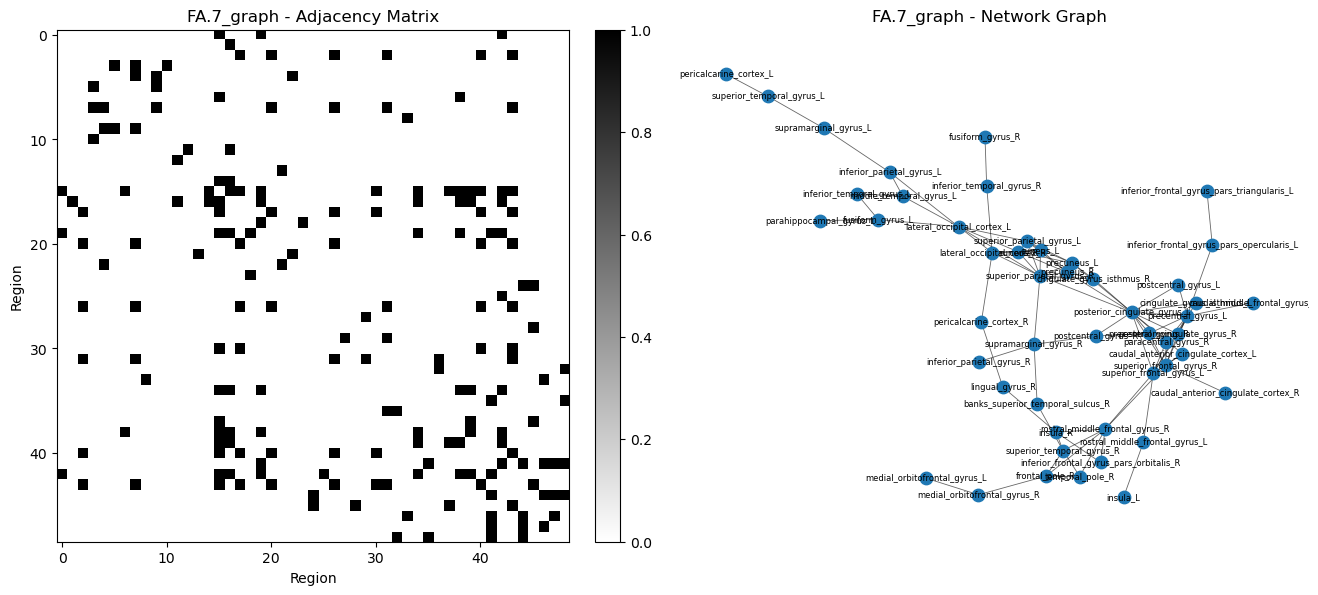

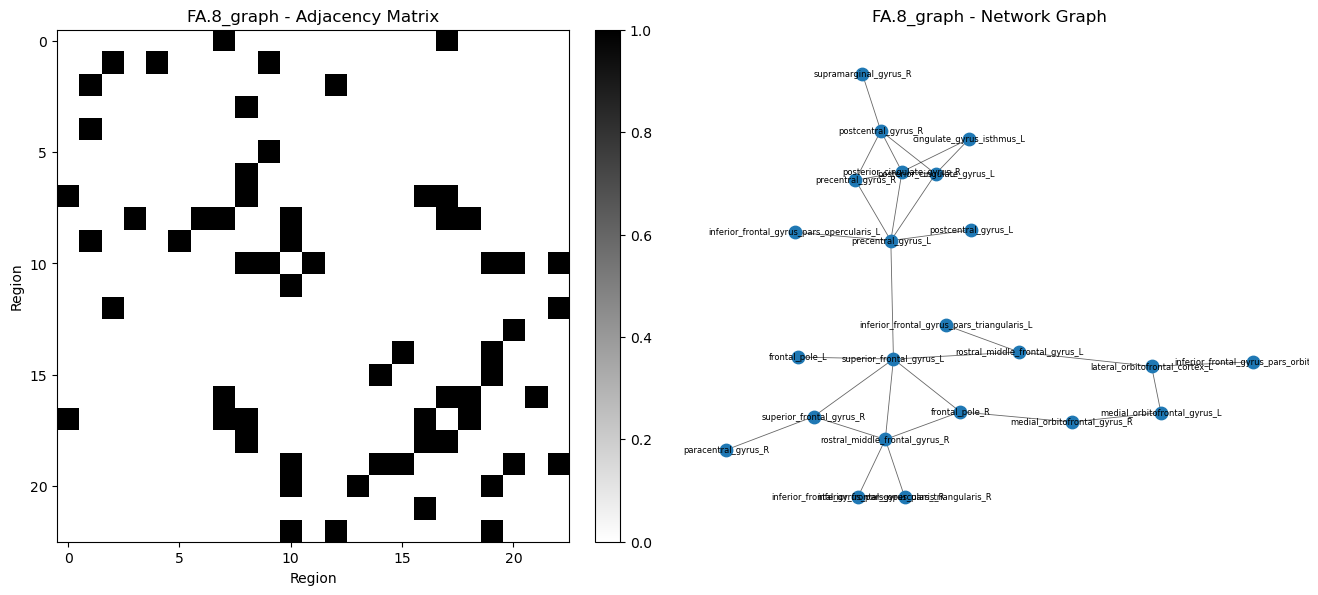

In [3]:

for file in files:
    data = load_graph_csv(file, get_largest_component=True)
    plot_connectome(data["matrix"], data["names"], title=Path(file).stem)

# edge density and mean shortest path


In [4]:
# edge density
def edge_density(matrix):
    n = matrix.shape[0]
    # If there are no nodes, density is 0
    if n == 0:
        return 0
    possible_edges = n * (n - 1) / 2
    if possible_edges == 0:
        return 0 # Avoid division by zero for single-node graphs
    actual_edges = np.sum(matrix > 0) / 2
    return actual_edges / possible_edges

def efficiency(matrix):
    """
    Average path length: the mean shortest path length between 
    pairs of vertices (efficiency)
    """
    G = nx.from_numpy_array(matrix)
    return nx.global_efficiency(G)

def mean_clustering_coeff(matrix):
    G = nx.from_numpy_array(matrix)
    return nx.average_clustering(G)

def get_metrics(matrix):
    G = nx.from_numpy_array(matrix)
    
    # These metrics work on the full (potentially disconnected) graph
    ed = edge_density(matrix)
    # Global efficiency is defined for disconnected graphs and is a good alternative to average shortest path length.
    eff = nx.global_efficiency(G) 
    mcc = nx.average_clustering(G)

    # Mean shortest path is only defined for connected graphs/components.
    # We calculate it on the largest component as is standard practice.
    if nx.is_connected(G):
        msp = nx.average_shortest_path_length(G)
    else:
        # Handle the case where the graph might be empty
        if G.number_of_nodes() == 0:
            msp = 0
        else:
            largest_cc = max(nx.connected_components(G), key=len)
            subgraph = G.subgraph(largest_cc)
            msp = nx.average_shortest_path_length(subgraph)
        
    return (ed, msp, eff, mcc)


metrics = {}
for file in files:
    # Load the full graph, NOT just the largest component
    data = load_graph_csv(file, get_largest_component=False) 
    file_mat = data["matrix"]
    print(f"Calculating metrics for {Path(file).name}...")
    mets = get_metrics(file_mat)
    print(mets)
    metrics[Path(file).stem.split("_")[0]] = mets

print(metrics)

Calculating metrics for FA.1_graph.csv...
(np.float64(0.11106233538191396), 2.688323090430202, 0.4413227977758171, 0.48797947534971753)
Calculating metrics for FA.2_graph.csv...
(np.float64(0.1093064091308165), 2.788410886742757, 0.4322139303482504, 0.51429573406217)
Calculating metrics for FA.3_graph.csv...
(np.float64(0.09569798068481124), 2.9477855477855477, 0.38941322797775363, 0.4517456399809341)
Calculating metrics for FA.4_graph.csv...
(np.float64(0.09043020193151888), 3.1465400271370423, 0.3845271193054312, 0.4992865794336382)
Calculating metrics for FA.5_graph.csv...
(np.float64(0.08121158911325724), 3.5822843822843824, 0.34300677982635863, 0.3980469309621559)
Calculating metrics for FA.6_graph.csv...
(np.float64(0.06628621597892889), 3.588524590163934, 0.2904286341402232, 0.3281880700998348)
Calculating metrics for FA.7_graph.csv...
(np.float64(0.04433713784021071), 3.7491496598639458, 0.182482386894153, 0.25491542770954534)
Calculating metrics for FA.8_graph.csv...
(np.float

In [5]:
import pandas as pd
#     return (ed,msp,eff,mcc)
metric_list = ["Edge Density", "Mean Shortest Path", "Efficiency", "Mean Clustering Coefficient"]
metrics_df = pd.DataFrame(metrics)
metrics_df.index = metric_list
print(metrics_df.T)

      Edge Density  Mean Shortest Path  Efficiency  \
FA.1      0.111062            2.688323    0.441323   
FA.2      0.109306            2.788411    0.432214   
FA.3      0.095698            2.947786    0.389413   
FA.4      0.090430            3.146540    0.384527   
FA.5      0.081212            3.582284    0.343007   
FA.6      0.066286            3.588525    0.290429   
FA.7      0.044337            3.749150    0.182482   
FA.8      0.028095            3.189723    0.075620   

      Mean Clustering Coefficient  
FA.1                     0.487979  
FA.2                     0.514296  
FA.3                     0.451746  
FA.4                     0.499287  
FA.5                     0.398047  
FA.6                     0.328188  
FA.7                     0.254915  
FA.8                     0.169608  


**Table 1:** Graph metrics for the structural connectome across FA thresholds. Mean shortest path length computed on the largest connected component; efficiency and clustering coefficient on the full graph.

| FA threshold | Edge density | Mean shortest path | Global efficiency | Clustering coeff. |
| --- | --- | --- | --- | --- |
| 0.1 | 0.111 | 2.688 | 0.441 | 0.488 |
| 0.2 | 0.109 | 2.788 | 0.432 | 0.514 |
| 0.3 | 0.096 | 2.948 | 0.389 | 0.452 |
| 0.4 | 0.090 | 3.147 | 0.385 | 0.499 |
| 0.5 | 0.081 | 3.582 | 0.343 | 0.398 |
| 0.6 | 0.066 | 3.589 | 0.290 | 0.328 |
| 0.7 | 0.044 | 3.749 | 0.182 | 0.255 |
| 0.8 | 0.028 | 3.190 | 0.076 | 0.170 |

In [6]:
# black background
plt.rcParams.update({
    "lines.color": "white",
    "patch.edgecolor": "white",
    "text.color": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "lightgray",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "grid.color": "lightgray",
    "figure.facecolor": "black",
    "legend.facecolor": "black",
    "figure.edgecolor": "black",
    "savefig.facecolor": "black",
    "savefig.edgecolor": "black"})





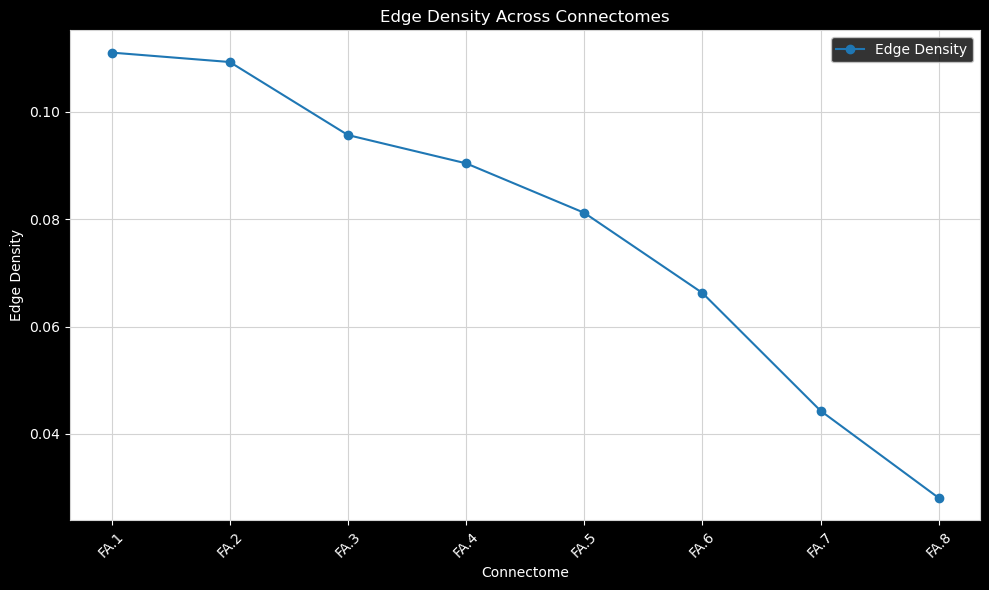

In [7]:
#  plot line chart for each metric

plt.figure(figsize=(10, 6))
edge_density_values = metrics_df.loc["Edge Density"]
plt.plot(edge_density_values.index, edge_density_values.values, marker="o", label="Edge Density")
plt.title("Edge Density Across Connectomes")
plt.xlabel("Connectome")
plt.ylabel("Edge Density")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

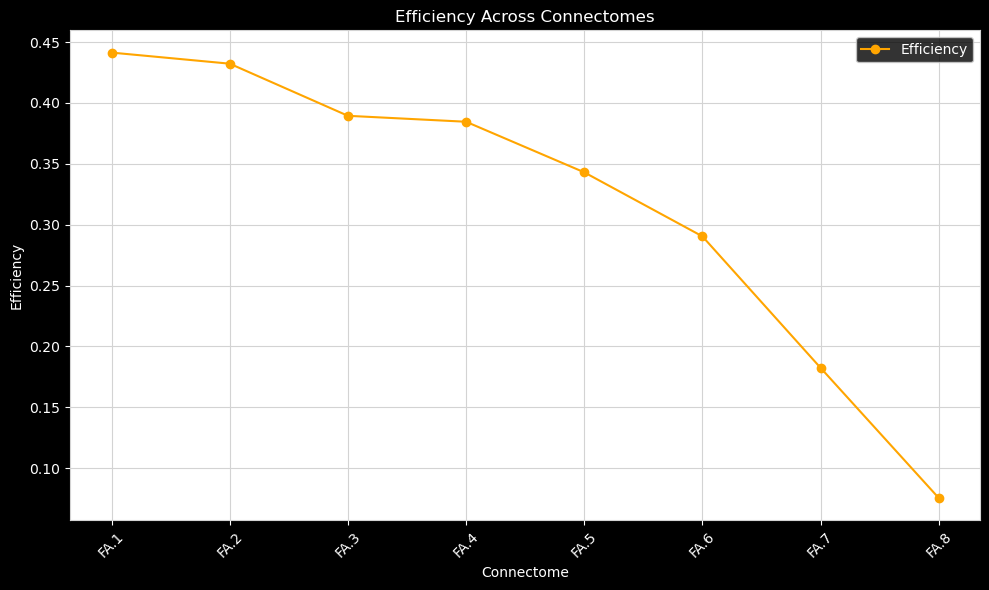

In [8]:
plt.figure(figsize=(10, 6))
efficiency_values = metrics_df.loc["Efficiency"]
plt.plot(efficiency_values.index, efficiency_values.values, marker="o", label="Efficiency", color="orange")
plt.title("Efficiency Across Connectomes")
plt.xlabel("Connectome")
plt.ylabel("Efficiency")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

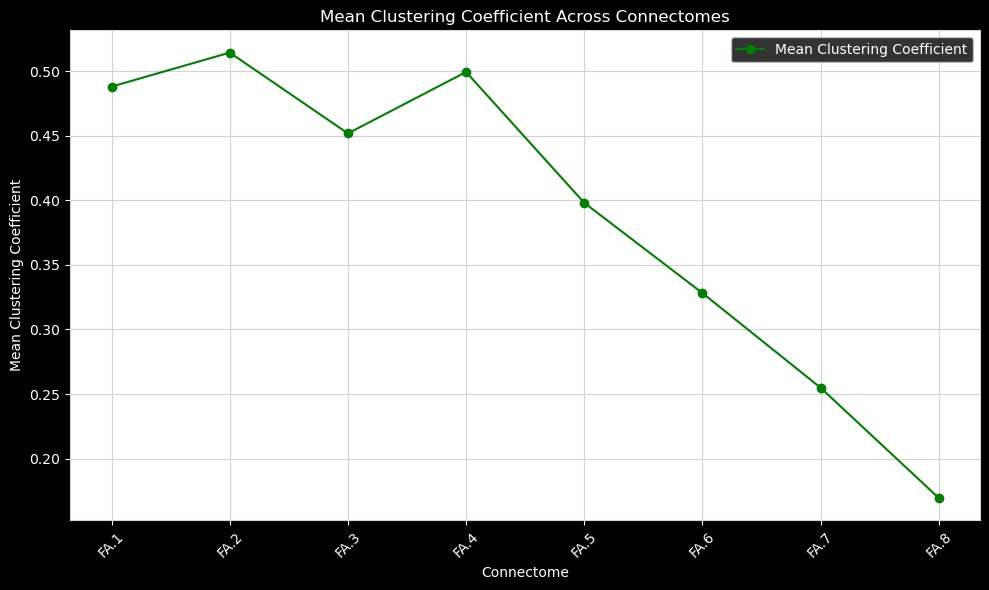

In [9]:
plt.figure(figsize=(10, 6))
mcc_values = metrics_df.loc["Mean Clustering Coefficient"]
plt.plot(mcc_values.index, mcc_values.values, marker="o", label="Mean Clustering Coefficient", color="green")
plt.title("Mean Clustering Coefficient Across Connectomes")
plt.xlabel("Connectome")
plt.ylabel("Mean Clustering Coefficient")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


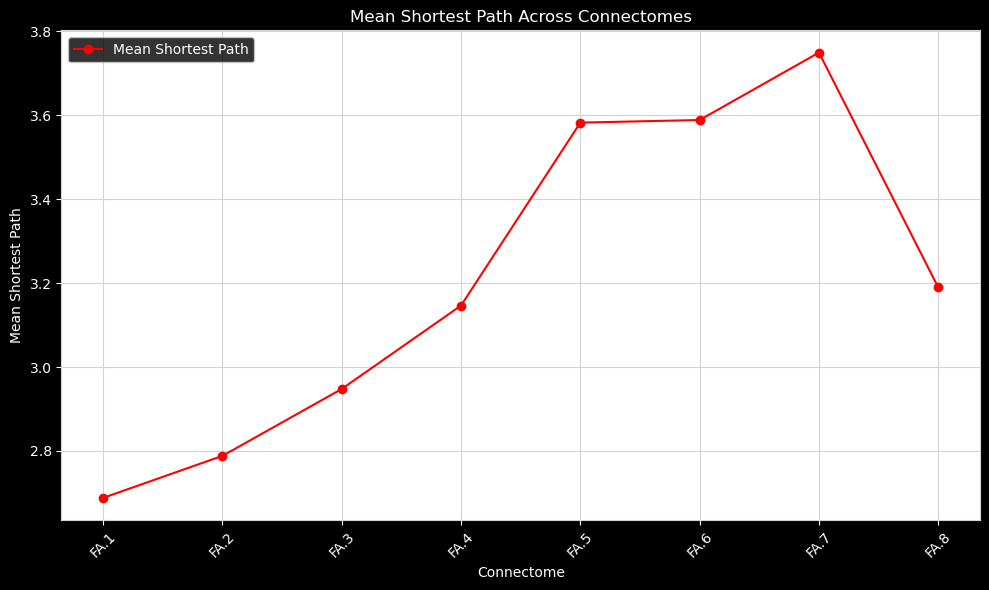

In [10]:
plt.figure(figsize=(10, 6))
mean_shortest_path_values = metrics_df.loc["Mean Shortest Path"]
plt.plot(mean_shortest_path_values.index, mean_shortest_path_values.values, marker="o", label="Mean Shortest Path", color="red")
plt.title("Mean Shortest Path Across Connectomes")
plt.xlabel("Connectome")
plt.ylabel("Mean Shortest Path")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Structural Connectome vs FA Threshold

Increasing the FA threshold progressively removes weaker fibres, reducing edge density from 11.1% to 2.8% and global efficiency from 0.441 to 0.076. Mean shortest path length increases from FA=0.1 to 0.7, then drops at FA=0.8. This drop at the end likely reflects the fragmentation of the graph at FA=0.8, where the largest connected component of the graph is small and dense. Clustering coefficient peaks at FA=0.2 then declines.